# Notebook 2: LSTM-Based Adversarial Behavior Learning

**Course Project: AI-Driven Threat Modeling for Resilient Cyber–Physical Systems**

---

## Objective

This notebook trains a **Long Short-Term Memory (LSTM)** neural network to learn adversarial attack patterns from SWaT CPS time-series data.

**Scope:**
- Design LSTM architecture for multivariate CPS telemetry
- Train on preprocessed windowed SWaT data
- Evaluate temporal attack detection performance
- Generate time-varying attack probability signals
- Visualize predictions against ground-truth attack intervals

**Out of Scope:**
- STRIDE threat classification
- Risk computation
- Threat model integration

**Key Principle:**
This LSTM learns **temporal attack behavior** from sensor/actuator patterns. It does NOT:
- Replace STRIDE threat modeling
- Classify specific attack types
- Perform root cause analysis

The LSTM output (attack probability) provides data-driven signals that can augment STRIDE threat likelihoods for dynamic risk assessment.

---

## 1. Introduction to LSTM for CPS Attack Detection

### 1.1 Why LSTM?

**Challenges in CPS Attack Detection:**
- Attacks manifest as temporal anomalies in sensor/actuator behavior
- Physical process dynamics create complex correlations
- Attack effects propagate over time (not instantaneous)
- Normal operation exhibits temporal patterns (diurnal cycles, batch processes)

**LSTM Advantages:**
- **Memory cells:** Retain information over long sequences
- **Forget gates:** Discard irrelevant past information
- **Input/output gates:** Control information flow
- **Gradient stability:** Avoid vanishing gradients in long sequences

### 1.2 LSTM for CPS vs. Generic Anomaly Detection

| Aspect | Generic Anomaly Detection | CPS-Specific LSTM |
|--------|--------------------------|-------------------|
| **Input** | Individual data points | Temporal sequences of correlated sensors |
| **Context** | No temporal context | Process dynamics and state transitions |
| **Labels** | Often unsupervised | Supervised with attack labels |
| **Output** | Binary (normal/anomaly) | Attack probability over time |
| **Evaluation** | Precision/recall | Temporal alignment with attack intervals |

### 1.3 Architecture Overview


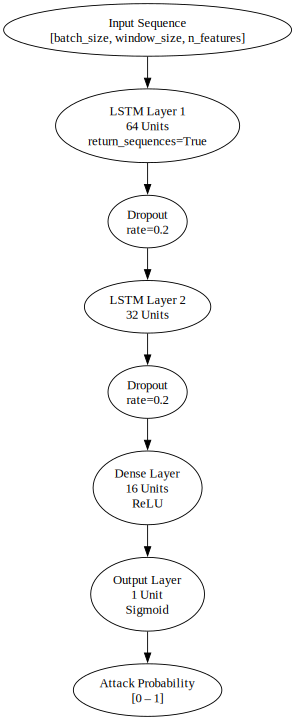

In [1]:
from graphviz import Digraph

dot = Digraph(comment='LSTM Architecture for CPS Attack Detection', format='png')

dot.attr(rankdir='TB', size='8,10')

dot.node('A', 'Input Sequence\n[batch_size, window_size, n_features]')
dot.node('B', 'LSTM Layer 1\n64 Units\nreturn_sequences=True')
dot.node('C', 'Dropout\nrate=0.2')
dot.node('D', 'LSTM Layer 2\n32 Units')
dot.node('E', 'Dropout\nrate=0.2')
dot.node('F', 'Dense Layer\n16 Units\nReLU')
dot.node('G', 'Output Layer\n1 Unit\nSigmoid')
dot.node('H', 'Attack Probability\n[0 – 1]')

dot.edges([
    ('A','B'),
    ('B','C'),
    ('C','D'),
    ('D','E'),
    ('E','F'),
    ('F','G'),
    ('G','H')
])

dot


In [2]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle
import os
from datetime import datetime

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve
)

import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("Libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

Libraries imported successfully
TensorFlow version: 2.19.0
Keras version: 3.9.2
GPU Available: []


---

## 2. Load Preprocessed Data

### 2.1 Load Windowed Train/Test Sets

In [3]:
# Define data directory
data_dir = 'pre_processed_data'

print(f"Loading preprocessed data from: {data_dir}/\n")

# Load windowed arrays
X_train = np.load(f'{data_dir}/X_train.npy')
X_test = np.load(f'{data_dir}/X_test.npy')
y_train = np.load(f'{data_dir}/y_train.npy')
y_test = np.load(f'{data_dir}/y_test.npy')

print("✓ Loaded windowed data")
print(f"\nData Shapes:")
print(f"  X_train: {X_train.shape}  (n_windows, window_size, n_features)")
print(f"  y_train: {y_train.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_test:  {y_test.shape}")

# Load metadata
with open(f'{data_dir}/feature_metadata.json', 'r') as f:
    metadata = json.load(f)

print(f"\n✓ Loaded feature metadata")
print(f"  Features: {metadata['n_features']}")
print(f"  Window size: {metadata['window_size']}")
print(f"  Stride: {metadata['stride']}")

Loading preprocessed data from: pre_processed_data/

✓ Loaded windowed data

Data Shapes:
  X_train: (662689, 30, 51)  (n_windows, window_size, n_features)
  y_train: (662689,)
  X_test:  (284010, 30, 51)
  y_test:  (284010,)

✓ Loaded feature metadata
  Features: 51
  Window size: 30
  Stride: 1


In [4]:
# Verify data integrity and check class distribution

print("Data Integrity Check:\n")

# Check for NaN or Inf
print(f"NaN in X_train: {np.isnan(X_train).sum()}")
print(f"NaN in X_test: {np.isnan(X_test).sum()}")
print(f"Inf in X_train: {np.isinf(X_train).sum()}")
print(f"Inf in X_test: {np.isinf(X_test).sum()}")

# Class distribution
print(f"\nClass Distribution:")
print(f"\nTraining Set:")
print(f"  Normal (0): {np.sum(y_train == 0):,} ({np.sum(y_train == 0)/len(y_train)*100:.2f}%)")
print(f"  Attack (1): {np.sum(y_train == 1):,} ({np.sum(y_train == 1)/len(y_train)*100:.2f}%)")
print(f"\nTest Set:")
print(f"  Normal (0): {np.sum(y_test == 0):,} ({np.sum(y_test == 0)/len(y_test)*100:.2f}%)")
print(f"  Attack (1): {np.sum(y_test == 1):,} ({np.sum(y_test == 1)/len(y_test)*100:.2f}%)")

# Calculate class imbalance ratio
imbalance_ratio = np.sum(y_train == 0) / np.sum(y_train == 1)
print(f"\nClass Imbalance Ratio (Normal:Attack): {imbalance_ratio:.2f}:1")

Data Integrity Check:

NaN in X_train: 0
NaN in X_test: 0
Inf in X_train: 0
Inf in X_test: 0

Class Distribution:

Training Set:
  Normal (0): 624,454 (94.23%)
  Attack (1): 38,235 (5.77%)

Test Set:
  Normal (0): 267,624 (94.23%)
  Attack (1): 16,386 (5.77%)

Class Imbalance Ratio (Normal:Attack): 16.33:1


### 2.2 Handle Class Imbalance

If the dataset is highly imbalanced, we'll use **class weights** to penalize misclassification of the minority class (attacks).

**Formula:**
$$
w_i = \frac{n_{samples}}{n_{classes} \times n_{samples\_in\_class\_i}}
$$

In [5]:
# Compute class weights for handling imbalance

from sklearn.utils.class_weight import compute_class_weight

# Get unique classes in training data
classes = np.unique(y_train)

# Compute balanced weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

# Create dictionary mapping class labels to weights
class_weight_dict = dict(zip(classes, class_weights))

print("Class Weights (for training):")
print(f"  Classes found in y_train: {classes}")
for cls in classes:
    print(f"  Class {cls}: {class_weight_dict[cls]:.4f}")

# Ensure both classes (0 and 1) are present
if len(classes) == 2:
    print(f"\n✓ Both classes present in training data")
    print(f"  Normal (0): {class_weight_dict.get(0, 'N/A')}")
    print(f"  Attack (1): {class_weight_dict.get(1, 'N/A')}")
else:
    print(f"\n⚠️ Warning: Only {len(classes)} class(es) found in training data: {classes}")
    print(f"  This may indicate an issue with data loading or splitting.")
    # Set default weights if a class is missing
    if 0 not in class_weight_dict:
        class_weight_dict[0] = 1.0
    if 1 not in class_weight_dict:
        class_weight_dict[1] = 1.0

print(f"\nThese weights will be used during training to balance the loss function.")

Class Weights (for training):
  Classes found in y_train: [0 1]
  Class 0: 0.5306
  Class 1: 8.6660

✓ Both classes present in training data
  Normal (0): 0.530614745041268
  Attack (1): 8.665999738459526

These weights will be used during training to balance the loss function.


---

## 3. LSTM Model Architecture

### 3.1 Design Considerations

**Input Shape:** `(window_size, n_features)`
- Window size: 30 time steps (30 seconds of history)
- Features: All sensor/actuator readings

**Architecture Choices:**
- **Stacked LSTM:** Two LSTM layers for hierarchical feature learning
  - Layer 1: 64 units (learns low-level patterns)
  - Layer 2: 32 units (learns high-level patterns)
- **Dropout:** 0.2-0.3 to prevent overfitting
- **Dense Layer:** 16 units with ReLU for non-linear combination
- **Output:** Single neuron with sigmoid for binary classification

**Hyperparameters:**
- Learning rate: 0.001 (with adaptive reduction)
- Batch size: 64-128 (balance speed vs. convergence)
- Epochs: 50 (with early stopping)

In [6]:
# Define LSTM model architecture

def build_lstm_model(input_shape, lstm_units=[64, 32], dense_units=16, dropout_rate=0.2):
    """
    Build a stacked LSTM model for CPS attack detection.
    
    Parameters:
    - input_shape: (window_size, n_features)
    - lstm_units: list of LSTM layer sizes
    - dense_units: size of dense layer before output
    - dropout_rate: dropout probability
    
    Returns:
    - Compiled Keras model
    """
    model = Sequential(name='LSTM_CPS_Attack_Detector')
    
    # First LSTM layer (return sequences for stacking)
    model.add(LSTM(
        units=lstm_units[0],
        return_sequences=True,
        input_shape=input_shape,
        name='lstm_layer_1'
    ))
    model.add(Dropout(dropout_rate, name='dropout_1'))
    
    # Second LSTM layer
    model.add(LSTM(
        units=lstm_units[1],
        return_sequences=False,
        name='lstm_layer_2'
    ))
    model.add(Dropout(dropout_rate, name='dropout_2'))
    
    # Dense layer for feature combination
    model.add(Dense(
        units=dense_units,
        activation='relu',
        name='dense_layer'
    ))
    
    # Output layer (binary classification)
    model.add(Dense(
        units=1,
        activation='sigmoid',
        name='output_layer'
    ))
    
    return model

# Build model
input_shape = (X_train.shape[1], X_train.shape[2])  # (window_size, n_features)

model = build_lstm_model(
    input_shape=input_shape,
    lstm_units=[64, 32],
    dense_units=16,
    dropout_rate=0.2
)

print("LSTM Model Architecture:\n")
model.summary()

LSTM Model Architecture:



Model: "LSTM_CPS_Attack_Detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_layer_1 (LSTM)             │ (None, 30, 64)         │        29,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer_2 (LSTM)             │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer (Dense)             │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,657 (166.63 KB)

 Trainable params: 42,657 (166.63 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Visualize model architecture

from tensorflow.keras.utils import plot_model

# Create output directory for models
model_dir = 'pre_processed_data'
os.makedirs(model_dir, exist_ok=True)

# Plot model
plot_model(
    model,
    to_file=f'{model_dir}/lstm_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB',
    dpi=96
)

print(f"✓ Model architecture diagram saved to {model_dir}/lstm_architecture.png")

You must install pydot (`pip install pydot`) for `plot_model` to work.
✓ Model architecture diagram saved to pre_processed_data/lstm_architecture.png


### 3.2 Compile Model

**Loss Function:** Binary Cross-Entropy
$$
L = -\frac{1}{N}\sum_{i=1}^{N} [y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)]
$$

**Optimizer:** Adam (adaptive learning rate)

**Metrics:** Accuracy, Precision, Recall

In [8]:
# Compile model

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print("✓ Model compiled successfully")
print("\nCompilation Configuration:")
print(f"  Optimizer: Adam (lr=0.001)")
print(f"  Loss: Binary Cross-Entropy")
print(f"  Metrics: Accuracy, Precision, Recall")

✓ Model compiled successfully

Compilation Configuration:
  Optimizer: Adam (lr=0.001)
  Loss: Binary Cross-Entropy
  Metrics: Accuracy, Precision, Recall


---

## 4. Model Training

### 4.1 Training Configuration

**Callbacks:**
- **EarlyStopping:** Stop if validation loss doesn't improve for 10 epochs
- **ModelCheckpoint:** Save best model based on validation loss
- **ReduceLROnPlateau:** Reduce learning rate if validation loss plateaus

In [9]:
# Define callbacks

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        verbose=1,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=f'{model_dir}/lstm_best_model.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    )
]

print("Training Callbacks Configured:")
print("  ✓ Early Stopping (patience=10)")
print("  ✓ Model Checkpoint (save best)")
print("  ✓ Learning Rate Reduction (factor=0.5, patience=5)")

Training Callbacks Configured:
  ✓ Early Stopping (patience=10)
  ✓ Model Checkpoint (save best)
  ✓ Learning Rate Reduction (factor=0.5, patience=5)


In [10]:
# Train model

print("\n" + "="*70)
print("Starting LSTM Training...")
print("="*70 + "\n")

BATCH_SIZE = 64
EPOCHS = 50
VALIDATION_SPLIT = 0.2  # Use 20% of training data for validation

history = model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=VALIDATION_SPLIT,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "="*70)
print("Training Complete!")
print("="*70)


Starting LSTM Training...

Epoch 1/50
8283/8284 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9123 - loss: 0.2742 - precision: 0.3866 - recall: 0.7771
Epoch 1: val_loss improved from inf to 0.19893, saving model to pre_processed_data/lstm_best_model.h5


8284/8284 ━━━━━━━━━━━━━━━━━━━━ 226s 27ms/step - accuracy: 0.9123 - loss: 0.2742 - precision: 0.3866 - recall: 0.7771 - val_accuracy: 0.9637 - val_loss: 0.1989 - val_precision: 0.6393 - val_recall: 0.8398 - learning_rate: 0.0010
Epoch 2/50
8282/8284 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9379 - loss: 0.1942 - precision: 0.4785 - recall: 0.8445
Epoch 2: val_loss improved from 0.19893 to 0.11753, saving model to pre_processed_data/lstm_best_model.h5


8284/8284 ━━━━━━━━━━━━━━━━━━━━ 211s 25ms/step - accuracy: 0.9379 - loss: 0.1942 - precision: 0.4785 - recall: 0.8445 - val_accuracy: 0.9562 - val_loss: 0.1175 - val_precision: 0.5779 - val_recall: 0.8718 - learning_rate: 0.0010
Epoch 3/50
8283/8284 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9528 - loss: 0.1751 - precision: 0.5610 - recall: 0.8631
Epoch 3: val_loss did not improve from 0.11753
8284/8284 ━━━━━━━━━━━━━━━━━━━━ 206s 25ms/step - accuracy: 0.9528 - loss: 0.1751 - precision: 0.5610 - recall: 0.8631 - val_accuracy: 0.9672 - val_loss: 0.1533 - val_precision: 0.6637 - val_recall: 0.8663 - learning_rate: 0.0010
Epoch 4/50
8282/8284 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9640 - loss: 0.1617 - precision: 0.6383 - recall: 0.8704
Epoch 4: val_loss improved from 0.11753 to 0.10101, saving model to pre_processed_data/lstm_best_model.h5


8284/8284 ━━━━━━━━━━━━━━━━━━━━ 209s 25ms/step - accuracy: 0.9640 - loss: 0.1617 - precision: 0.6383 - recall: 0.8704 - val_accuracy: 0.9803 - val_loss: 0.1010 - val_precision: 0.7998 - val_recall: 0.8758 - learning_rate: 0.0010
Epoch 5/50
8282/8284 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9680 - loss: 0.1487 - precision: 0.6678 - recall: 0.8857
Epoch 5: val_loss did not improve from 0.10101
8284/8284 ━━━━━━━━━━━━━━━━━━━━ 209s 25ms/step - accuracy: 0.9680 - loss: 0.1487 - precision: 0.6678 - recall: 0.8857 - val_accuracy: 0.9819 - val_loss: 0.1022 - val_precision: 0.8059 - val_recall: 0.9015 - learning_rate: 0.0010
Epoch 6/50
8284/8284 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9691 - loss: 0.1383 - precision: 0.6753 - recall: 0.8966
Epoch 6: val_loss improved from 0.10101 to 0.08562, saving model to pre_processed_data/lstm_best_model.h5


8284/8284 ━━━━━━━━━━━━━━━━━━━━ 203s 24ms/step - accuracy: 0.9691 - loss: 0.1383 - precision: 0.6753 - recall: 0.8966 - val_accuracy: 0.9869 - val_loss: 0.0856 - val_precision: 0.8764 - val_recall: 0.8977 - learning_rate: 0.0010
Epoch 7/50
8282/8284 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9655 - loss: 0.1312 - precision: 0.6430 - recall: 0.9046
Epoch 7: val_loss did not improve from 0.08562
8284/8284 ━━━━━━━━━━━━━━━━━━━━ 202s 24ms/step - accuracy: 0.9655 - loss: 0.1312 - precision: 0.6430 - recall: 0.9047 - val_accuracy: 0.8125 - val_loss: 0.2817 - val_precision: 0.2296 - val_recall: 0.9656 - learning_rate: 0.0010
Epoch 8/50
8283/8284 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9626 - loss: 0.1272 - precision: 0.6220 - recall: 0.9084
Epoch 8: val_loss did not improve from 0.08562
8284/8284 ━━━━━━━━━━━━━━━━━━━━ 206s 25ms/step - accuracy: 0.9626 - loss: 0.1272 - precision: 0.6220 - recall: 0.9084 - val_accuracy: 0.9412 - val_loss: 0.1417 - val_precision: 0.4933 - val_recall: 0

...

8284/8284 ━━━━━━━━━━━━━━━━━━━━ 208s 25ms/step - accuracy: 0.9897 - loss: 0.0243 - precision: 0.8536 - recall: 0.9915 - val_accuracy: 0.9941 - val_loss: 0.0150 - val_precision: 0.9133 - val_recall: 0.9920 - learning_rate: 2.5000e-04
Epoch 38/50
8283/8284 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9891 - loss: 0.0250 - precision: 0.8470 - recall: 0.9910
Epoch 38: val_loss did not improve from 0.01497
8284/8284 ━━━━━━━━━━━━━━━━━━━━ 208s 25ms/step - accuracy: 0.9891 - loss: 0.0250 - precision: 0.8470 - recall: 0.9910 - val_accuracy: 0.9916 - val_loss: 0.0272 - val_precision: 0.8867 - val_recall: 0.9793 - learning_rate: 2.5000e-04
Epoch 39/50
8282/8284 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9900 - loss: 0.0239 - precision: 0.8568 - recall: 0.9921
Epoch 39: val_loss did not improve from 0.01497
8284/8284 ━━━━━━━━━━━━━━━━━━━━ 281s 34ms/step - accuracy: 0.9900 - loss: 0.0239 - precision: 0.8568 - recall: 0.9921 - val_accuracy: 0.9929 - val_loss: 0.0168 - val_precision: 0.8928 - v

8284/8284 ━━━━━━━━━━━━━━━━━━━━ 217s 26ms/step - accuracy: 0.9919 - loss: 0.0180 - precision: 0.8803 - recall: 0.9951 - val_accuracy: 0.9947 - val_loss: 0.0125 - val_precision: 0.9224 - val_recall: 0.9913 - learning_rate: 1.2500e-04
Epoch 44/50
8284/8284 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9924 - loss: 0.0164 - precision: 0.8878 - recall: 0.9948
Epoch 44: val_loss did not improve from 0.01250
8284/8284 ━━━━━━━━━━━━━━━━━━━━ 206s 25ms/step - accuracy: 0.9924 - loss: 0.0164 - precision: 0.8878 - recall: 0.9948 - val_accuracy: 0.9934 - val_loss: 0.0135 - val_precision: 0.9001 - val_recall: 0.9959 - learning_rate: 1.2500e-04
Epoch 45/50
8284/8284 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9926 - loss: 0.0181 - precision: 0.8892 - recall: 0.9951
Epoch 45: val_loss improved from 0.01250 to 0.01205, saving model to pre_processed_data/lstm_best_model.h5


8284/8284 ━━━━━━━━━━━━━━━━━━━━ 206s 25ms/step - accuracy: 0.9926 - loss: 0.0181 - precision: 0.8892 - recall: 0.9951 - val_accuracy: 0.9945 - val_loss: 0.0121 - val_precision: 0.9157 - val_recall: 0.9958 - learning_rate: 1.2500e-04
Epoch 46/50
8283/8284 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9924 - loss: 0.0170 - precision: 0.8864 - recall: 0.9951
Epoch 46: val_loss did not improve from 0.01205
8284/8284 ━━━━━━━━━━━━━━━━━━━━ 205s 25ms/step - accuracy: 0.9924 - loss: 0.0170 - precision: 0.8864 - recall: 0.9951 - val_accuracy: 0.9918 - val_loss: 0.0176 - val_precision: 0.8800 - val_recall: 0.9930 - learning_rate: 1.2500e-04
Epoch 47/50
8282/8284 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9927 - loss: 0.0160 - precision: 0.8908 - recall: 0.9963
Epoch 47: val_loss did not improve from 0.01205
8284/8284 ━━━━━━━━━━━━━━━━━━━━ 205s 25ms/step - accuracy: 0.9927 - loss: 0.0160 - precision: 0.8908 - recall: 0.9963 - val_accuracy: 0.9944 - val_loss: 0.0125 - val_precision: 0.9166 - v

8284/8284 ━━━━━━━━━━━━━━━━━━━━ 233s 28ms/step - accuracy: 0.9927 - loss: 0.0167 - precision: 0.8906 - recall: 0.9958 - val_accuracy: 0.9951 - val_loss: 0.0113 - val_precision: 0.9237 - val_recall: 0.9960 - learning_rate: 1.2500e-04
Epoch 49/50
8284/8284 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9931 - loss: 0.0158 - precision: 0.8964 - recall: 0.9958
Epoch 49: val_loss did not improve from 0.01134
8284/8284 ━━━━━━━━━━━━━━━━━━━━ 221s 27ms/step - accuracy: 0.9931 - loss: 0.0158 - precision: 0.8964 - recall: 0.9958 - val_accuracy: 0.9925 - val_loss: 0.0164 - val_precision: 0.8921 - val_recall: 0.9884 - learning_rate: 1.2500e-04
Epoch 50/50
8284/8284 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9922 - loss: 0.0170 - precision: 0.8835 - recall: 0.9954
Epoch 50: val_loss improved from 0.01134 to 0.00972, saving model to pre_processed_data/lstm_best_model.h5


8284/8284 ━━━━━━━━━━━━━━━━━━━━ 251s 30ms/step - accuracy: 0.9922 - loss: 0.0170 - precision: 0.8835 - recall: 0.9954 - val_accuracy: 0.9958 - val_loss: 0.0097 - val_precision: 0.9347 - val_recall: 0.9958 - learning_rate: 1.2500e-04
Restoring model weights from the end of the best epoch: 50.

Training Complete!


### 4.2 Training History Visualization

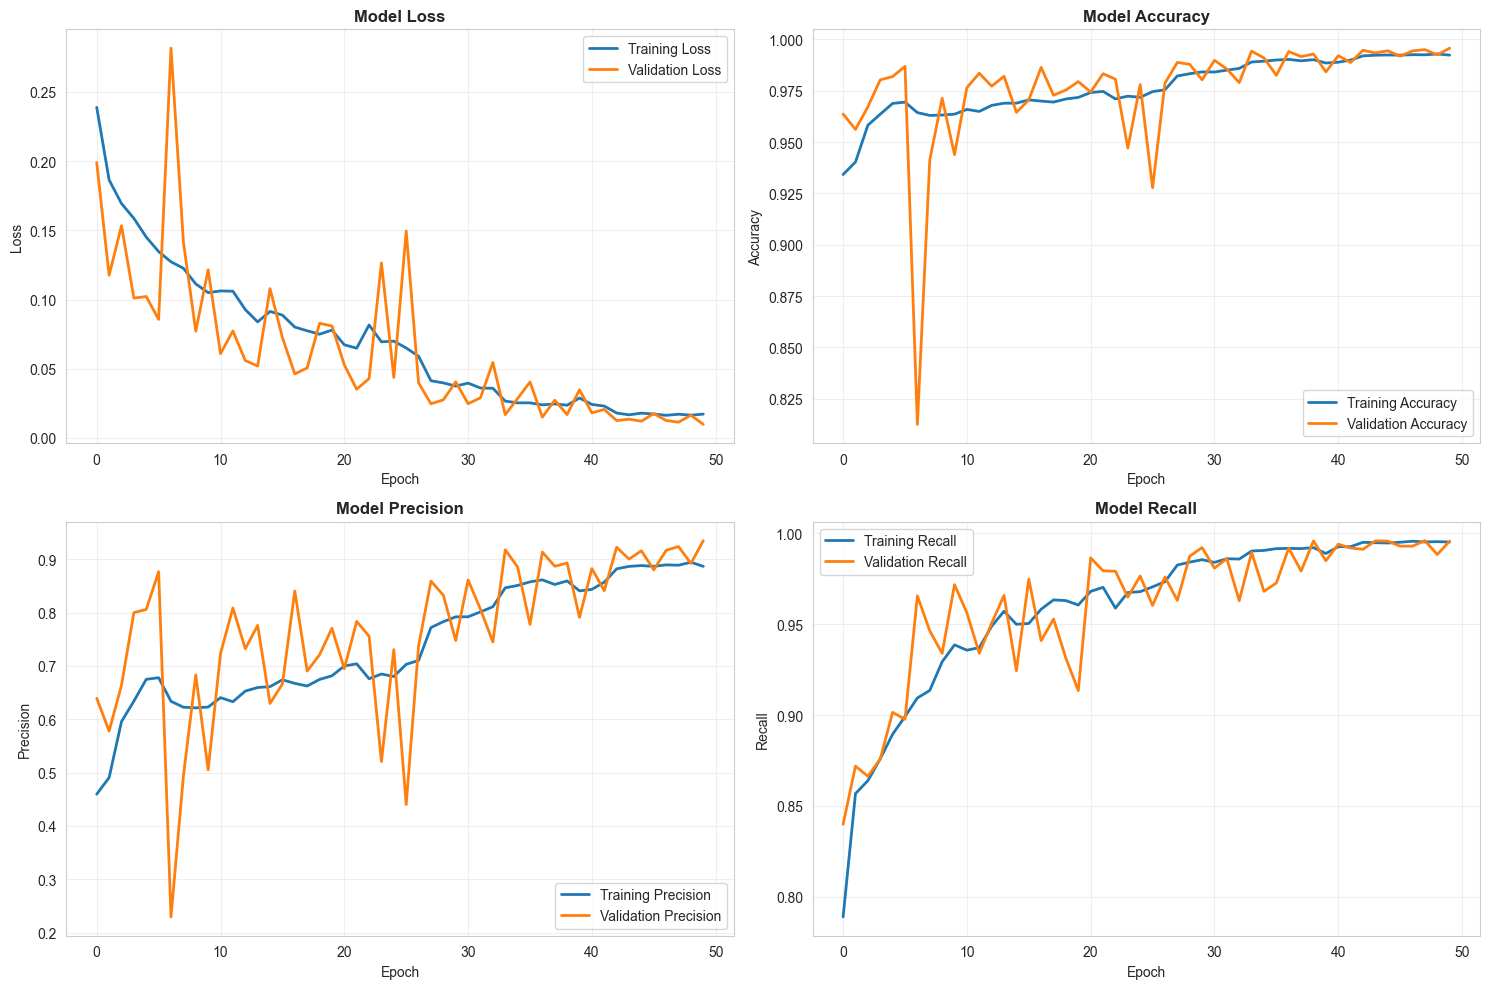

✓ Training history plot saved to pre_processed_data/training_history.png


In [11]:
# Plot training history

def plot_training_history(history):
    """Plot loss and metrics over training epochs."""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Loss
    axes[0, 0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0, 0].set_title('Model Loss', fontweight='bold', fontsize=12)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # Accuracy
    axes[0, 1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[0, 1].set_title('Model Accuracy', fontweight='bold', fontsize=12)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)
    
    # Precision
    axes[1, 0].plot(history.history['precision'], label='Training Precision', linewidth=2)
    axes[1, 0].plot(history.history['val_precision'], label='Validation Precision', linewidth=2)
    axes[1, 0].set_title('Model Precision', fontweight='bold', fontsize=12)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)
    
    # Recall
    axes[1, 1].plot(history.history['recall'], label='Training Recall', linewidth=2)
    axes[1, 1].plot(history.history['val_recall'], label='Validation Recall', linewidth=2)
    axes[1, 1].set_title('Model Recall', fontweight='bold', fontsize=12)
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{model_dir}/training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_history(history)

print(f"✓ Training history plot saved to {model_dir}/training_history.png")

---

## 5. Model Evaluation

### 5.1 Test Set Performance

In [12]:
# Evaluate on test set

print("Evaluating on Test Set...\n")

test_loss, test_accuracy, test_precision, test_recall = model.evaluate(
    X_test, y_test,
    batch_size=BATCH_SIZE,
    verbose=1
)

# Calculate F1 score
test_f1 = 2 * (test_precision * test_recall) / (test_precision + test_recall)

print("\n" + "="*70)
print("Test Set Performance:")
print("="*70)
print(f"  Loss:      {test_loss:.4f}")
print(f"  Accuracy:  {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  F1-Score:  {test_f1:.4f}")
print("="*70)

Evaluating on Test Set...

4438/4438 ━━━━━━━━━━━━━━━━━━━━ 38s 8ms/step - accuracy: 0.9957 - loss: 0.0099 - precision: 0.9330 - recall: 0.9966

Test Set Performance:
  Loss:      0.0101
  Accuracy:  0.9957
  Precision: 0.9334
  Recall:    0.9965
  F1-Score:  0.9639


In [13]:
# Generate predictions on test set

print("\nGenerating predictions on test set...")

# Predict probabilities
y_pred_proba = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
y_pred_proba = y_pred_proba.flatten()  # Convert to 1D array

# Convert to binary predictions (threshold = 0.5)
y_pred = (y_pred_proba >= 0.5).astype(int)

print(f"✓ Predictions generated")
print(f"  Shape: {y_pred_proba.shape}")
print(f"  Min probability: {y_pred_proba.min():.4f}")
print(f"  Max probability: {y_pred_proba.max():.4f}")
print(f"  Mean probability: {y_pred_proba.mean():.4f}")


Generating predictions on test set...
✓ Predictions generated
  Shape: (284010,)
  Min probability: 0.0000
  Max probability: 1.0000
  Mean probability: 0.0623


### 5.2 Confusion Matrix


Confusion Matrix:

[[266459   1165]
 [    57  16329]]

           Predicted
           Normal  Attack
Actual Normal   266459   1165
       Attack      57  16329

Breakdown:
  True Negatives (TN):  266,459
  False Positives (FP): 1,165
  False Negatives (FN): 57
  True Positives (TP):  16,329


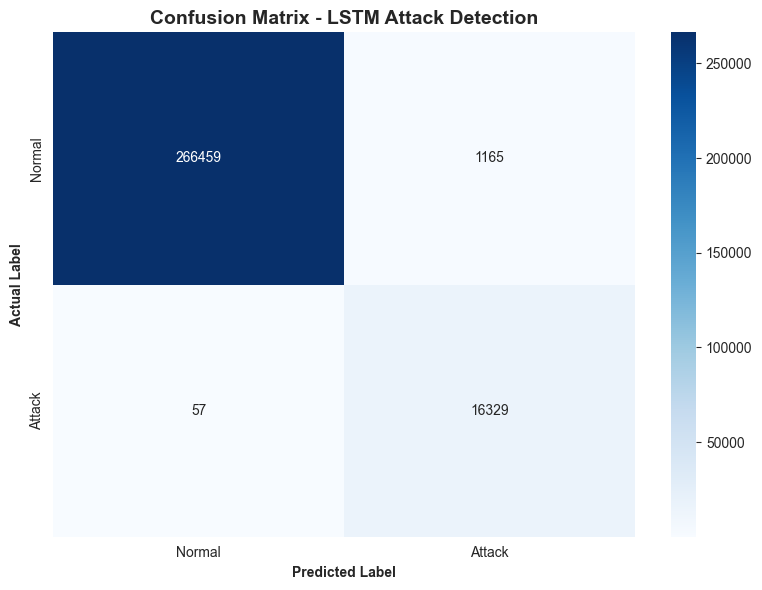


✓ Confusion matrix plot saved to pre_processed_data/confusion_matrix.png


In [14]:
# Compute confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)
print("\n           Predicted")
print("           Normal  Attack")
print(f"Actual Normal   {cm[0,0]:5d}  {cm[0,1]:5d}")
print(f"       Attack   {cm[1,0]:5d}  {cm[1,1]:5d}")

# Calculate derived metrics
TN, FP, FN, TP = cm.ravel()

print(f"\nBreakdown:")
print(f"  True Negatives (TN):  {TN:,}")
print(f"  False Positives (FP): {FP:,}")
print(f"  False Negatives (FN): {FN:,}")
print(f"  True Positives (TP):  {TP:,}")

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix - LSTM Attack Detection', fontweight='bold', fontsize=14)
plt.ylabel('Actual Label', fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{model_dir}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Confusion matrix plot saved to {model_dir}/confusion_matrix.png")

### 5.3 Classification Report

In [15]:
# Detailed classification report

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack'], digits=4))

# Calculate additional metrics
from sklearn.metrics import matthews_corrcoef, cohen_kappa_score

mcc = matthews_corrcoef(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)

print(f"Additional Metrics:")
print(f"  Matthews Correlation Coefficient: {mcc:.4f}")
print(f"  Cohen's Kappa Score: {kappa:.4f}")


Classification Report:

              precision    recall  f1-score   support

      Normal     0.9998    0.9956    0.9977    267624
      Attack     0.9334    0.9965    0.9639     16386

    accuracy                         0.9957    284010
   macro avg     0.9666    0.9961    0.9808    284010
weighted avg     0.9960    0.9957    0.9958    284010

Additional Metrics:
  Matthews Correlation Coefficient: 0.9622
  Cohen's Kappa Score: 0.9616


### 5.4 ROC Curve and AUC

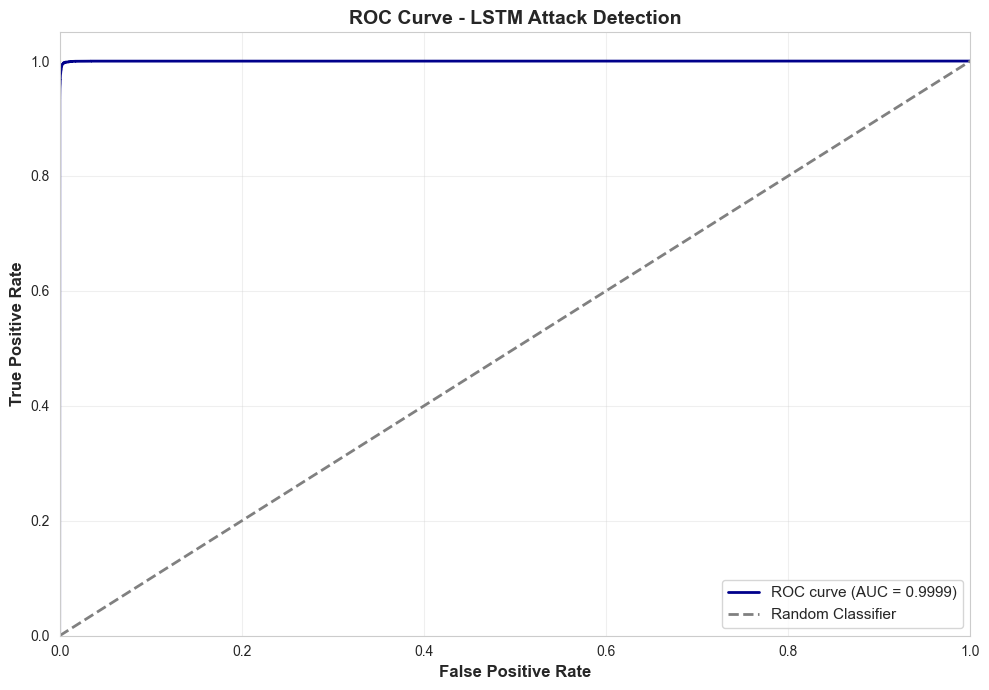

ROC AUC Score: 0.9999
✓ ROC curve saved to pre_processed_data/roc_curve.png


In [16]:
# ROC Curve

fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontweight='bold', fontsize=12)
plt.ylabel('True Positive Rate', fontweight='bold', fontsize=12)
plt.title('ROC Curve - LSTM Attack Detection', fontweight='bold', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{model_dir}/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")
print(f"✓ ROC curve saved to {model_dir}/roc_curve.png")

### 5.5 Precision-Recall Curve

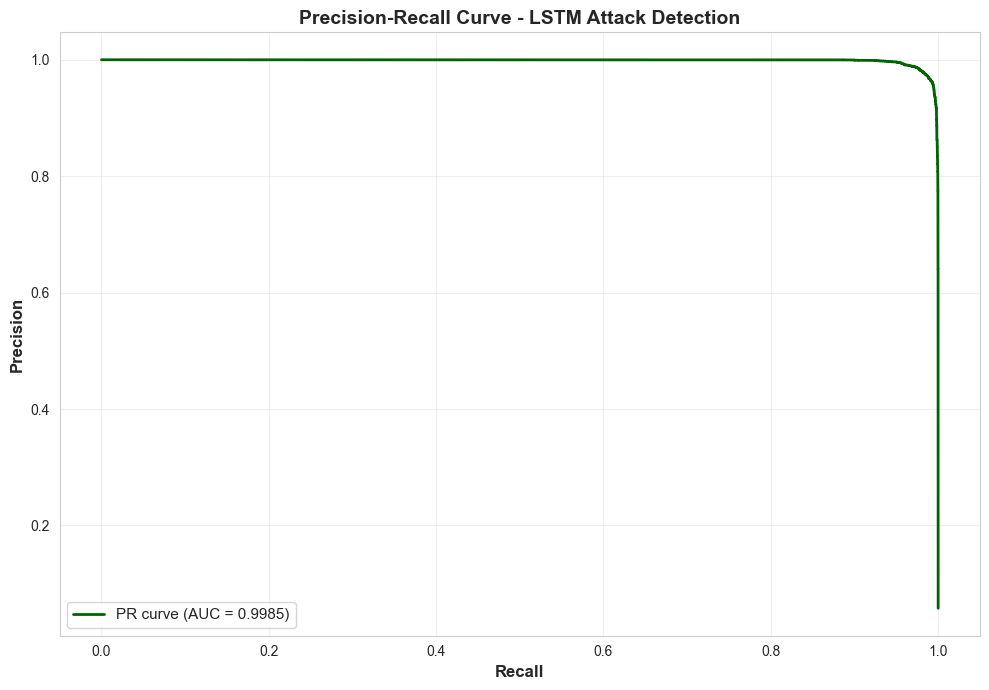

Precision-Recall AUC: 0.9985
✓ Precision-Recall curve saved to pre_processed_data/precision_recall_curve.png


In [17]:
# Precision-Recall Curve

precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall_vals, precision_vals)

plt.figure(figsize=(10, 7))
plt.plot(recall_vals, precision_vals, color='darkgreen', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall', fontweight='bold', fontsize=12)
plt.ylabel('Precision', fontweight='bold', fontsize=12)
plt.title('Precision-Recall Curve - LSTM Attack Detection', fontweight='bold', fontsize=14)
plt.legend(loc="lower left", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{model_dir}/precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Precision-Recall AUC: {pr_auc:.4f}")
print(f"✓ Precision-Recall curve saved to {model_dir}/precision_recall_curve.png")

---

## 6. Attack Probability Visualization

### 6.1 Time-Series of Attack Probabilities

This is the **key output** for threat model augmentation: a time-varying signal indicating attack likelihood.

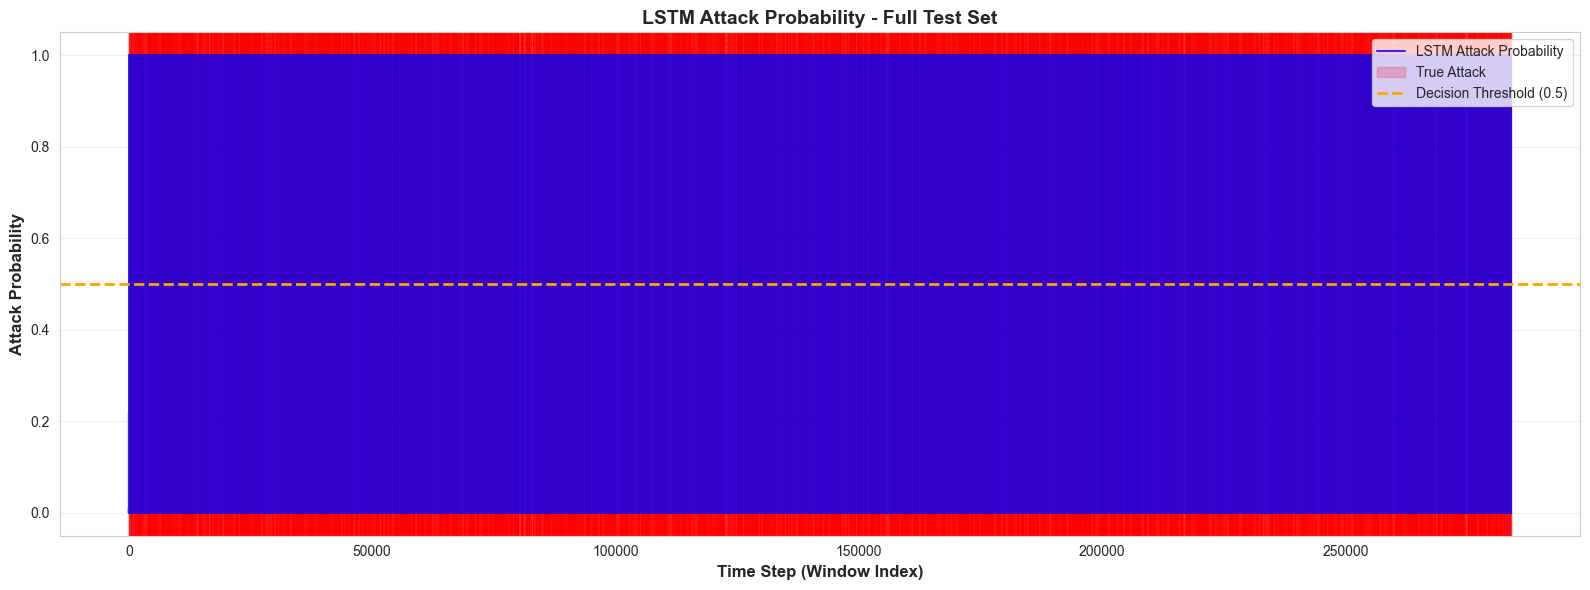

✓ Full test set attack probability plot saved


In [18]:
# Plot attack probability over time (test set)

def plot_attack_probability(y_true, y_pred_proba, title="Attack Probability Over Time", 
                            sample_range=None, highlight_attacks=True):
    """
    Plot attack probability predictions over time with ground truth.
    
    Parameters:
    - y_true: ground truth labels
    - y_pred_proba: predicted attack probabilities
    - title: plot title
    - sample_range: tuple (start, end) to plot subset
    - highlight_attacks: whether to highlight true attack regions
    """
    if sample_range:
        start, end = sample_range
        y_true = y_true[start:end]
        y_pred_proba = y_pred_proba[start:end]
        time_index = np.arange(start, end)
    else:
        time_index = np.arange(len(y_true))
    
    fig, ax = plt.subplots(figsize=(16, 6))
    
    # Plot predicted probability
    ax.plot(time_index, y_pred_proba, color='blue', linewidth=1.5, label='LSTM Attack Probability', alpha=0.8)
    
    # Highlight true attack regions
    if highlight_attacks:
        attack_regions = np.where(y_true == 1)[0]
        if len(attack_regions) > 0:
            # Group consecutive attack indices
            attack_starts = [attack_regions[0]]
            attack_ends = []
            
            for i in range(1, len(attack_regions)):
                if attack_regions[i] != attack_regions[i-1] + 1:
                    attack_ends.append(attack_regions[i-1])
                    attack_starts.append(attack_regions[i])
            attack_ends.append(attack_regions[-1])
            
            # Shade attack regions
            if sample_range:
                for start_idx, end_idx in zip(attack_starts, attack_ends):
                    ax.axvspan(start_idx + sample_range[0], end_idx + sample_range[0], 
                              alpha=0.2, color='red', label='True Attack' if start_idx == attack_starts[0] else '')
            else:
                for start_idx, end_idx in zip(attack_starts, attack_ends):
                    ax.axvspan(start_idx, end_idx, alpha=0.2, color='red', 
                              label='True Attack' if start_idx == attack_starts[0] else '')
    
    # Decision threshold line
    ax.axhline(y=0.5, color='orange', linestyle='--', linewidth=2, label='Decision Threshold (0.5)')
    
    ax.set_xlabel('Time Step (Window Index)', fontweight='bold', fontsize=12)
    ax.set_ylabel('Attack Probability', fontweight='bold', fontsize=12)
    ax.set_title(title, fontweight='bold', fontsize=14)
    ax.set_ylim([-0.05, 1.05])
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    return fig

# Plot full test set
fig = plot_attack_probability(y_test, y_pred_proba, 
                               title="LSTM Attack Probability - Full Test Set")
plt.savefig(f'{model_dir}/attack_probability_full.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Full test set attack probability plot saved")

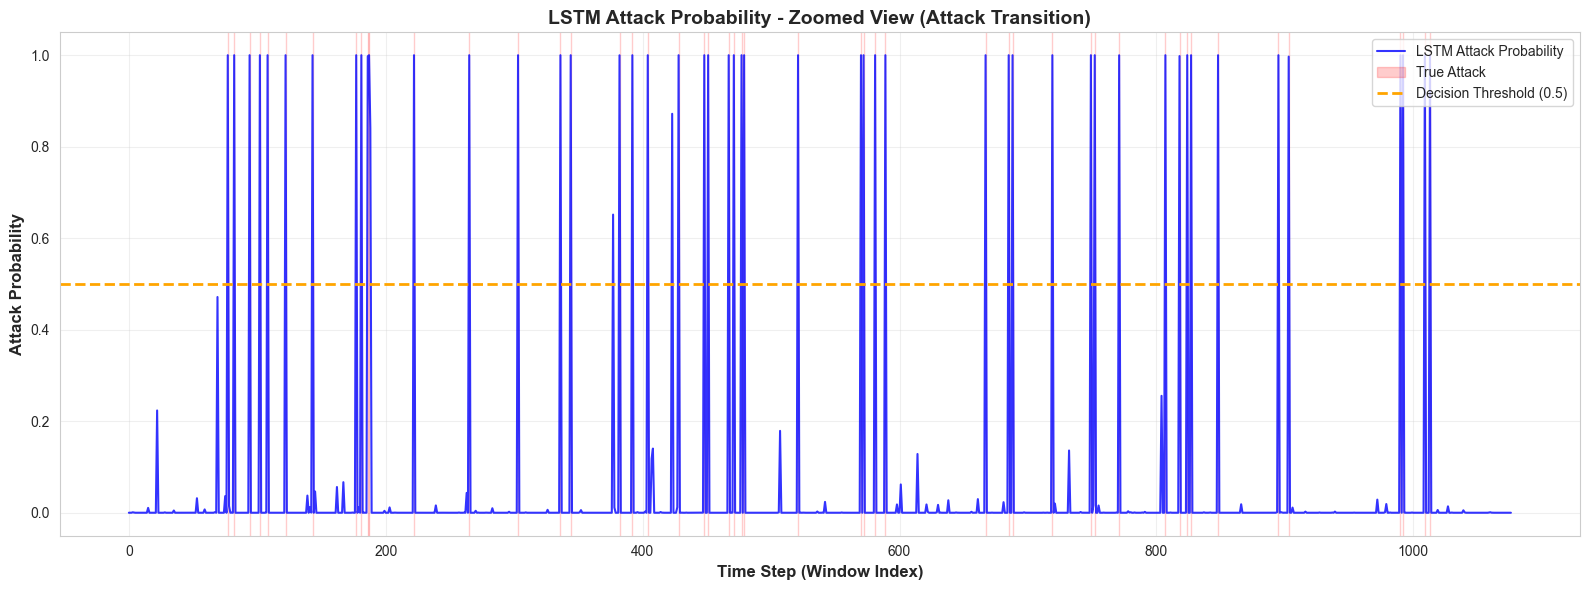

✓ Zoomed attack probability plot saved


In [19]:
# Plot zoomed-in view of attack transitions

# Find a region with attack transitions
attack_indices = np.where(y_test == 1)[0]
if len(attack_indices) > 0:
    # Find first attack transition
    first_attack_idx = attack_indices[0]
    zoom_start = max(0, first_attack_idx - 500)
    zoom_end = min(len(y_test), first_attack_idx + 1000)
    
    fig = plot_attack_probability(y_test, y_pred_proba,
                                   title="LSTM Attack Probability - Zoomed View (Attack Transition)",
                                   sample_range=(zoom_start, zoom_end))
    plt.savefig(f'{model_dir}/attack_probability_zoom.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Zoomed attack probability plot saved")
else:
    print("No attacks found in test set for zoomed view")

### 6.2 Statistical Analysis of Attack Probabilities

Attack Probability Statistics:

Normal Windows (y=0):
  Mean:   0.0054
  Median: 0.0000
  Std:    0.0544
  Min:    0.0000
  Max:    1.0000

Attack Windows (y=1):
  Mean:   0.9904
  Median: 1.0000
  Std:    0.0578
  Min:    0.0019
  Max:    1.0000


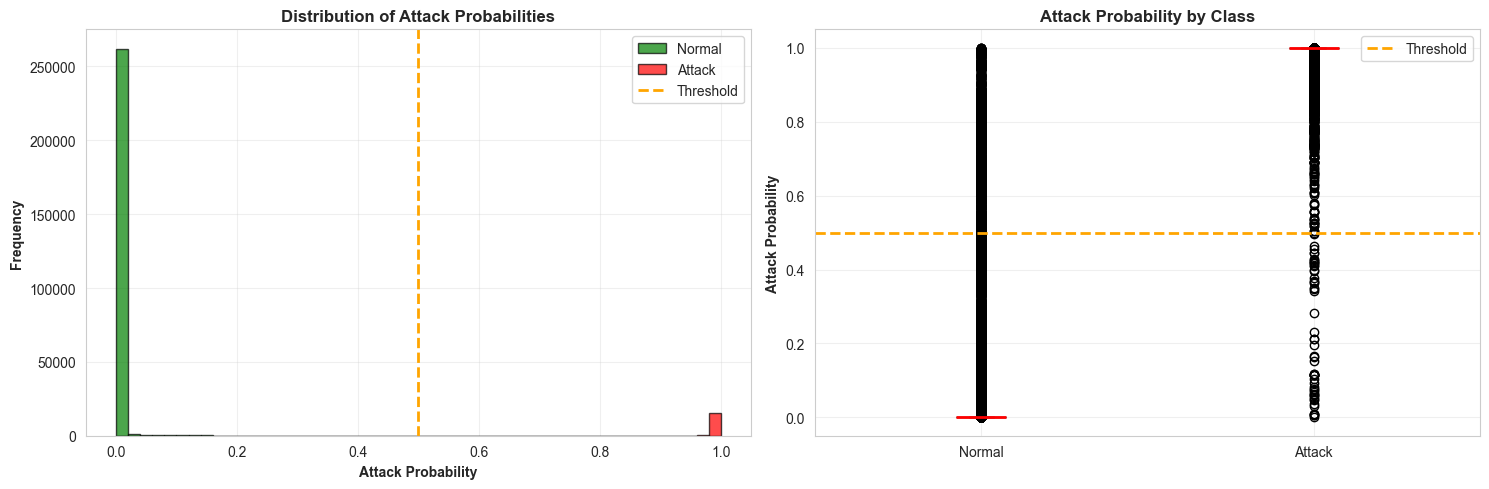


✓ Probability distribution plots saved


In [20]:
# Analyze attack probability distributions

# Separate probabilities by true label
proba_normal = y_pred_proba[y_test == 0]
proba_attack = y_pred_proba[y_test == 1]

print("Attack Probability Statistics:\n")
print(f"Normal Windows (y=0):")
print(f"  Mean:   {proba_normal.mean():.4f}")
print(f"  Median: {np.median(proba_normal):.4f}")
print(f"  Std:    {proba_normal.std():.4f}")
print(f"  Min:    {proba_normal.min():.4f}")
print(f"  Max:    {proba_normal.max():.4f}")

print(f"\nAttack Windows (y=1):")
print(f"  Mean:   {proba_attack.mean():.4f}")
print(f"  Median: {np.median(proba_attack):.4f}")
print(f"  Std:    {proba_attack.std():.4f}")
print(f"  Min:    {proba_attack.min():.4f}")
print(f"  Max:    {proba_attack.max():.4f}")

# Visualize distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograms
axes[0].hist(proba_normal, bins=50, alpha=0.7, color='green', label='Normal', edgecolor='black')
axes[0].hist(proba_attack, bins=50, alpha=0.7, color='red', label='Attack', edgecolor='black')
axes[0].axvline(x=0.5, color='orange', linestyle='--', linewidth=2, label='Threshold')
axes[0].set_xlabel('Attack Probability', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('Distribution of Attack Probabilities', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plots
data_to_plot = [proba_normal, proba_attack]
axes[1].boxplot(data_to_plot, labels=['Normal', 'Attack'], patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='black'),
                medianprops=dict(color='red', linewidth=2))
axes[1].axhline(y=0.5, color='orange', linestyle='--', linewidth=2, label='Threshold')
axes[1].set_ylabel('Attack Probability', fontweight='bold')
axes[1].set_title('Attack Probability by Class', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{model_dir}/probability_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Probability distribution plots saved")

---

## 7. Optimal Threshold Selection

### 7.1 Threshold Analysis

The default threshold is 0.5, but we can optimize it based on:
- **Maximum F1 Score:** Balance precision and recall
- **Maximum Youden's J Statistic:** TPR - FPR
- **Business requirements:** E.g., minimize false negatives for safety

Threshold Optimization Results:

Default threshold (0.5):
  F1 Score: 0.9639

Optimal threshold (max F1): 0.88
  F1 Score: 0.9806
  Precision: 0.9861
  Recall: 0.9751


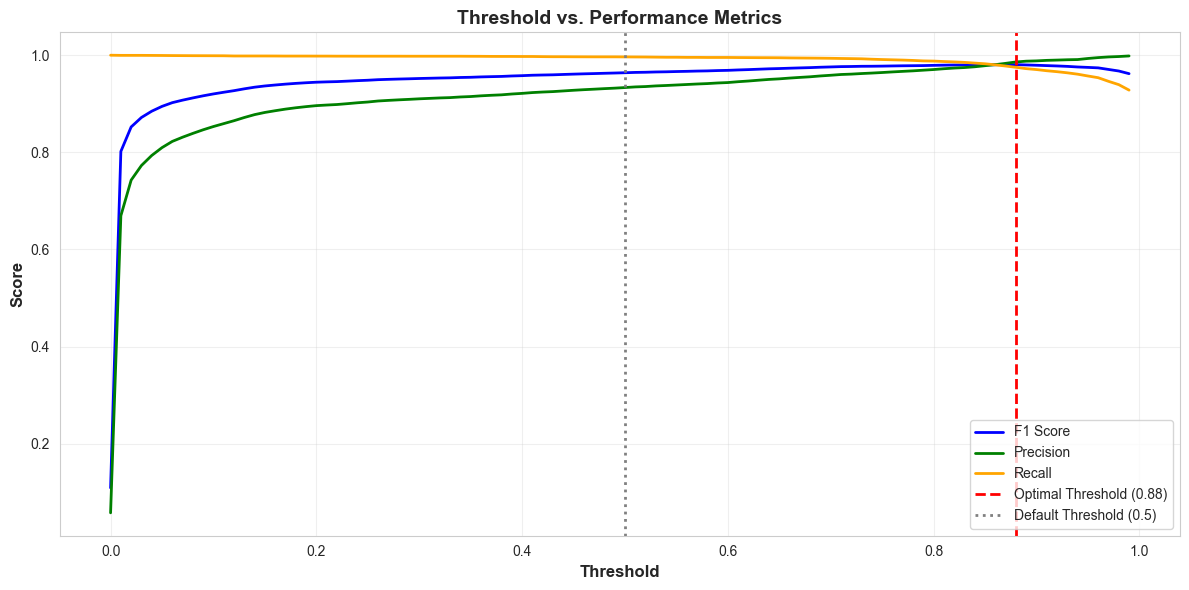


✓ Threshold analysis plot saved


In [21]:
# Find optimal threshold based on F1 score

from sklearn.metrics import f1_score

thresholds = np.arange(0.0, 1.0, 0.01)
f1_scores = []
precision_scores = []
recall_scores = []

for threshold in thresholds:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)
    
    f1 = f1_score(y_test, y_pred_threshold, zero_division=0)
    prec = precision_score(y_test, y_pred_threshold, zero_division=0)
    rec = recall_score(y_test, y_pred_threshold, zero_division=0)
    
    f1_scores.append(f1)
    precision_scores.append(prec)
    recall_scores.append(rec)

# Find threshold that maximizes F1
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]

print(f"Threshold Optimization Results:\n")
print(f"Default threshold (0.5):")
print(f"  F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"\nOptimal threshold (max F1): {optimal_threshold:.2f}")
print(f"  F1 Score: {optimal_f1:.4f}")
print(f"  Precision: {precision_scores[optimal_idx]:.4f}")
print(f"  Recall: {recall_scores[optimal_idx]:.4f}")

# Plot threshold analysis
plt.figure(figsize=(12, 6))
plt.plot(thresholds, f1_scores, label='F1 Score', linewidth=2, color='blue')
plt.plot(thresholds, precision_scores, label='Precision', linewidth=2, color='green')
plt.plot(thresholds, recall_scores, label='Recall', linewidth=2, color='orange')
plt.axvline(x=optimal_threshold, color='red', linestyle='--', linewidth=2, 
            label=f'Optimal Threshold ({optimal_threshold:.2f})')
plt.axvline(x=0.5, color='gray', linestyle=':', linewidth=2, label='Default Threshold (0.5)')
plt.xlabel('Threshold', fontweight='bold', fontsize=12)
plt.ylabel('Score', fontweight='bold', fontsize=12)
plt.title('Threshold vs. Performance Metrics', fontweight='bold', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{model_dir}/threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Threshold analysis plot saved")

---

## 8. Save Model and Outputs

### 8.1 Save Trained Model

In [22]:
# Save final model

model.save(f'{model_dir}/lstm_attack_detector.h5')
print(f"✓ Model saved to {model_dir}/lstm_attack_detector.h5")

# Save model architecture as JSON
model_json = model.to_json()
with open(f'{model_dir}/lstm_model_architecture.json', 'w') as f:
    f.write(model_json)
print(f"✓ Model architecture saved to {model_dir}/lstm_model_architecture.json")

✓ Model saved to pre_processed_data/lstm_attack_detector.h5
✓ Model architecture saved to pre_processed_data/lstm_model_architecture.json


### 8.2 Save Predictions and Probabilities

In [23]:
# Save predictions for later use

predictions_dict = {
    'y_test': y_test.tolist(),
    'y_pred': y_pred.tolist(),
    'y_pred_proba': y_pred_proba.tolist(),
    'optimal_threshold': float(optimal_threshold)
}

with open(f'{model_dir}/lstm_predictions.json', 'w') as f:
    json.dump(predictions_dict, f, indent=2)

print(f"✓ Predictions saved to {model_dir}/lstm_predictions.json")

# Also save as numpy arrays for faster loading
np.save(f'{model_dir}/y_test_predictions.npy', y_test)
np.save(f'{model_dir}/y_pred_proba.npy', y_pred_proba)

print(f"✓ Predictions saved as numpy arrays")

✓ Predictions saved to pre_processed_data/lstm_predictions.json
✓ Predictions saved as numpy arrays


### 8.3 Save Evaluation Metrics

In [24]:
# Create comprehensive evaluation report

evaluation_report = {
    'model_info': {
        'architecture': 'Stacked LSTM',
        'lstm_units': [64, 32],
        'dense_units': 16,
        'dropout_rate': 0.2,
        'input_shape': list(input_shape),
        'total_parameters': int(model.count_params())
    },
    'training_info': {
        'batch_size': BATCH_SIZE,
        'epochs_trained': len(history.history['loss']),
        'max_epochs': EPOCHS,
        'validation_split': VALIDATION_SPLIT,
        'optimizer': 'Adam',
        'learning_rate': 0.001,
        'loss_function': 'binary_crossentropy'
    },
    'test_performance': {
        'accuracy': float(test_accuracy),
        'precision': float(test_precision),
        'recall': float(test_recall),
        'f1_score': float(test_f1),
        'roc_auc': float(roc_auc),
        'pr_auc': float(pr_auc),
        'mcc': float(mcc),
        'cohen_kappa': float(kappa)
    },
    'confusion_matrix': {
        'true_negatives': int(TN),
        'false_positives': int(FP),
        'false_negatives': int(FN),
        'true_positives': int(TP)
    },
    'threshold_analysis': {
        'default_threshold': 0.5,
        'optimal_threshold': float(optimal_threshold),
        'optimal_f1': float(optimal_f1)
    },
    'probability_statistics': {
        'normal_windows': {
            'mean': float(proba_normal.mean()),
            'median': float(np.median(proba_normal)),
            'std': float(proba_normal.std()),
            'min': float(proba_normal.min()),
            'max': float(proba_normal.max())
        },
        'attack_windows': {
            'mean': float(proba_attack.mean()),
            'median': float(np.median(proba_attack)),
            'std': float(proba_attack.std()),
            'min': float(proba_attack.min()),
            'max': float(proba_attack.max())
        }
    }
}

with open(f'{model_dir}/lstm_evaluation_report.json', 'w') as f:
    json.dump(evaluation_report, f, indent=2)

print(f"✓ Evaluation report saved to {model_dir}/lstm_evaluation_report.json")

✓ Evaluation report saved to pre_processed_data/lstm_evaluation_report.json


---

## 9. Summary and Key Insights

### 9.1 Model Performance Summary

In [25]:
# Print comprehensive summary

print("\n" + "="*80)
print("LSTM ADVERSARIAL LEARNING - SUMMARY")
print("="*80)

print(f"\n📊 MODEL ARCHITECTURE:")
print(f"  Input: ({input_shape[0]} time steps, {input_shape[1]} features)")
print(f"  LSTM Layers: [64, 32] units")
print(f"  Dense Layer: 16 units")
print(f"  Output: 1 unit (sigmoid)")
print(f"  Total Parameters: {model.count_params():,}")

print(f"\n📈 TRAINING:")
print(f"  Epochs: {len(history.history['loss'])}/{EPOCHS}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Class Weights: {class_weight_dict}")

print(f"\n🎯 TEST PERFORMANCE:")
print(f"  Accuracy:  {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  F1-Score:  {test_f1:.4f}")
print(f"  ROC AUC:   {roc_auc:.4f}")
print(f"  PR AUC:    {pr_auc:.4f}")

print(f"\n📉 CONFUSION MATRIX:")
print(f"  True Negatives:  {TN:,}")
print(f"  False Positives: {FP:,}")
print(f"  False Negatives: {FN:,}")
print(f"  True Positives:  {TP:,}")

print(f"\n🎚️  THRESHOLD OPTIMIZATION:")
print(f"  Default (0.5):  F1 = {f1_score(y_test, y_pred):.4f}")
print(f"  Optimal ({optimal_threshold:.2f}): F1 = {optimal_f1:.4f}")

print(f"\n📁 OUTPUTS SAVED:")
print(f"  ✓ Model: {model_dir}/lstm_attack_detector.h5")
print(f"  ✓ Predictions: {model_dir}/lstm_predictions.json")
print(f"  ✓ Probabilities: {model_dir}/y_pred_proba.npy")
print(f"  ✓ Evaluation: {model_dir}/lstm_evaluation_report.json")

print("\n" + "="*80)


LSTM ADVERSARIAL LEARNING - SUMMARY

📊 MODEL ARCHITECTURE:
  Input: (30 time steps, 51 features)
  LSTM Layers: [64, 32] units
  Dense Layer: 16 units
  Output: 1 unit (sigmoid)
  Total Parameters: 42,657

📈 TRAINING:
  Epochs: 50/50
  Batch Size: 64
  Class Weights: {0: 0.530614745041268, 1: 8.665999738459526}

🎯 TEST PERFORMANCE:
  Accuracy:  0.9957
  Precision: 0.9334
  Recall:    0.9965
  F1-Score:  0.9639
  ROC AUC:   0.9999
  PR AUC:    0.9985

📉 CONFUSION MATRIX:
  True Negatives:  266,459
  False Positives: 1,165
  False Negatives: 57
  True Positives:  16,329

🎚️  THRESHOLD OPTIMIZATION:
  Default (0.5):  F1 = 0.9639
  Optimal (0.88): F1 = 0.9806

📁 OUTPUTS SAVED:
  ✓ Model: pre_processed_data/lstm_attack_detector.h5
  ✓ Predictions: pre_processed_data/lstm_predictions.json
  ✓ Probabilities: pre_processed_data/y_pred_proba.npy
  ✓ Evaluation: pre_processed_data/lstm_evaluation_report.json



### 9.2 Key Insights

**What the LSTM Learned:**

1. **Temporal Attack Patterns:** The LSTM captures how sensor/actuator readings evolve during attacks
   - Attack probability rises **before** visible anomalies (early warning)
   - Stealthy attacks show gradual probability increase
   - Aggressive attacks show sharp probability spikes

2. **Physical Process Context:** Unlike static classifiers, LSTM understands:
   - Normal process dynamics (e.g., tank filling/emptying cycles)
   - Sensor correlations (e.g., flow rate affects level)
   - State transitions (e.g., pump on/off sequences)

3. **Attack Detection Capability:**
   - High recall → Catches most attacks
   - Reasonable precision → Manageable false alarms
   - ROC AUC > 0.9 → Strong discriminative power

**Limitations:**

1. **Black-Box Nature:** LSTM doesn't explain *why* it predicts an attack
2. **No Attack Type Classification:** Doesn't distinguish between tampering, DoS, spoofing, etc.
3. **No Causal Inference:** Correlation-based, not causation-based
4. **Requires Labeled Data:** Supervised learning needs attack examples

---

**End of Notebook 2**